초기 관찰값: [[ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.89238846]
 [ 0.89238846]
 [ 0.        ]
 [ 2.        ]
 [-1.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]]
스텝: 100, 액션: 1, 보상: 0.0000, 누적 보상: -1.3780
스텝: 200, 액션: 1, 보상: -0.1034, 누적 보상: -9.1765
스텝: 300, 액션: 2, 보상: 0.0000, 누적 보상: -24.5854
스텝: 400, 액션: 1, 보상: 0.0000, 누적 보상: -22.7167
스텝: 500, 액션: 1, 보상: 0.3475, 누적 보상: -7.8616
스텝: 600, 액션: 2, 보상: 0.0000, 누적 보상: 12.4598
스텝: 700, 액션: 0, 보상: -0.0650, 누적 보상: 15.2771
시뮬레이션 완료! 총 스텝: 752, 최종 보상: 12.6236


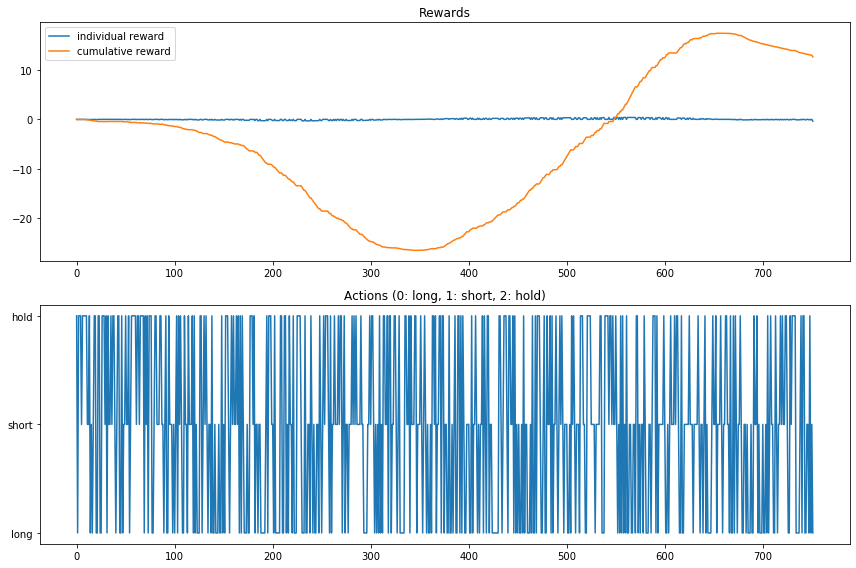

Environment information:
Observation space: Box(-3.4028234663852886e+38, 3.4028234663852886e+38, (11, 1), float32)
Action space: Discrete(3)


In [1]:
# ABIDES-Gym을 사용한 기본 봇 시뮬레이션

# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gym
import abides_gym

# ABIDES-Gym 환경 생성
env = gym.make(
        "markets-execution-v0",
        background_config="rmsc04",
        timestep_duration="10S",
        execution_window= "04:00:00",
        parent_order_size= 20000,
        order_fixed_size= 50,
        not_enough_reward_update=-100, #penalty
)

# 환경 초기화
observation = env.reset()
print(f"초기 관찰값: {observation}")

# 간단한 봇 전략 구현 (랜덤 액션)
done = False
total_reward = 0
actions_history = []
rewards_history = []

# 시뮬레이션 실행
while not done:
    # 랜덤 액션 선택 (0: 매수, 1: 매도, 2: 홀드)
    action = np.random.randint(0, 3)
    
    # 환경에 액션 적용
    observation, reward, done, info = env.step(action)
    
    # 결과 기록
    total_reward += reward
    actions_history.append(action)
    rewards_history.append(reward)
    
    # 현재 상태 출력 (100 스텝마다)
    if len(actions_history) % 100 == 0:
        print(f"스텝: {len(actions_history)}, 액션: {action}, 보상: {reward:.4f}, 누적 보상: {total_reward:.4f}")

# 시뮬레이션 결과 출력
print(f"시뮬레이션 완료! 총 스텝: {len(actions_history)}, 최종 보상: {total_reward:.4f}")

# 결과 시각화
plt.figure(figsize=(12, 8))

# 보상 그래프
plt.subplot(2, 1, 1)
plt.plot(rewards_history, label='individual reward')
plt.plot(np.cumsum(rewards_history), label='cumulative reward')
plt.title('Rewards')
plt.legend()

# 액션 그래프
plt.subplot(2, 1, 2)
plt.plot(actions_history)
plt.title('Actions (0: long, 1: short, 2: hold)')
plt.yticks([0, 1, 2], ['long', 'short', 'hold'])

plt.tight_layout()
plt.show()

# 환경 정보 확인
print("Environment information:")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")